# Paying the Capital: Analyzing Salary Patterns Across Washington, DC Public Agencies

This project examines a dataset of Washington, DC public employee salaries, including job titles, agencies, hire dates, appointment types, and annual compensation. Public salary data is released by the DC government to promote transparency and allow residents to understand how public funds are allocated across departments and roles.

This dataset is analytically compelling because it captures real-world workforce structure, compensation patterns, and agency-level differences across a major U.S. city. By analyzing salary distributions, job categories, and agency trends, we can uncover meaningful insights about how public resources are distributed.


## Objective and Research Questions

**Objective:**  
To analyze salary patterns among Washington, DC public employees and identify the factors associated with higher compensation.

**Research Questions:**  
1. How do salaries vary across agencies in Washington, DC?  
2. Which job titles and job categories are associated with higher compensation?  
3. What features (agency, job title, appointment type, hire date) correlate most strongly with higher salaries?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("DC_Public_Employee_Salary.csv")
df.head()


,FIRST_NAME,LAST_NAME,JOBTITLE,DESCRSHORT,GRADE,COMPRATE,HIREDATE_STRING,GVT_TYPE_OF_APPT,OBJECTID
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5


In [3]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()


,first_name,last_name,jobtitle,descrshort,grade,comprate,hiredate_string,gvt_type_of_appt,objectid
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5


In [4]:
df = df.rename(columns={'descrshort': 'agency'})


In [5]:
df['comprate'] = df['comprate'].astype(float)


In [6]:
df['hiredate'] = pd.to_datetime(df['hiredate_string'], errors='coerce')


In [7]:
df = df.drop_duplicates()


In [8]:
df.isna().sum()


first_name           0
last_name            0
jobtitle             0
agency               0
grade               40
comprate             0
hiredate_string      0
gvt_type_of_appt     0
objectid             0
hiredate             0
dtype: int64

In [9]:
df.head()


,first_name,last_name,jobtitle,agency,grade,comprate,hiredate_string,gvt_type_of_appt,objectid,hiredate
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004/10/18,CS - Reg,1,2004-10-18
1,Korlu,Wolobah-Kuyon,PSYCHIATRIC NURSE,DBH,09,115907.00,2020/08/17,CS - Reg,2,2020-08-17
2,Hadizat,Elayo-Ross,SUPERVISORY PSYCHIATRIC NURSE,DBH,13,122500.00,2023/08/14,MSS - Reg,3,2023-08-14
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985/08/27,CS - Reg,4,1985-08-27
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016/11/14,CS - Reg,5,2016-11-14


In [10]:
df.describe()


,comprate,objectid,hiredate
count,40611.000000,40611.000000,40611
mean,89087.755572,20306.000000,2014-09-07 06:01:36.269483776
min,0.030000,1.000000,1966-07-30 00:00:00
25%,66130.000000,10153.500000,2008-06-26 12:00:00
50%,93234.000000,20306.000000,2016-12-14 00:00:00
75%,119643.130000,30458.500000,2022-09-06 00:00:00
max,390232.000000,40611.000000,2025-12-30 00:00:00
std,47453.788915,11723.530228,NaN


In [11]:
df['comprate'].describe()


count     40611.000000
mean      89087.755572
std       47453.788915
min           0.030000
25%       66130.000000
50%       93234.000000
75%      119643.130000
max      390232.000000
Name: comprate, dtype: float64

In [12]:
df['agency'].value_counts().head(15)


agency
DCPS        11764
MPD          4123
FEMS         2366
UDC          1716
DPW          1480
OCFO         1386
DBH          1248
DDOT         1212
DHS          1182
OSSE DOT     1177
DOC          1073
DOH           801
DOES          718
OAG           674
CFSA          654
Name: count, dtype: int64

In [13]:
df['jobtitle'].value_counts().head(15)


jobtitle
OFFICER                        2027
Teacher, General Elementary    1369
Teacher, Special Ed.           1011
FIREFIGHTER EMT                 971
Teacher, General Secondary      828
SUBSTITUTE TEACHER              807
Program Analyst                 697
CORRECTIONAL OFFICER            646
Motor Vehicle Operator          566
Aide, 10mo Special Ed           539
Bus Attendant                   509
SERGEANT                        469
Adjunct Professor-SEIU          437
Teacher, Early Childhood        415
SANITATION WORKER               350
Name: count, dtype: int64

In [14]:
df['gvt_type_of_appt'].value_counts()


gvt_type_of_appt
CS - Reg      19794
Ed - Reg      12311
MSS - Reg      2516
CS - Term      2078
Ed - Temp      1913
LS - Reg        602
ExS - Reg       566
CS - Temp       522
LS - Term        69
Ed - Term        62
Exe - Reg        61
MSS - Temp       36
MSS - Term       28
ExS - Term       20
ExS - Temp       16
Acting            9
Exe - Term        5
Exe - Temp        3
Name: count, dtype: int64

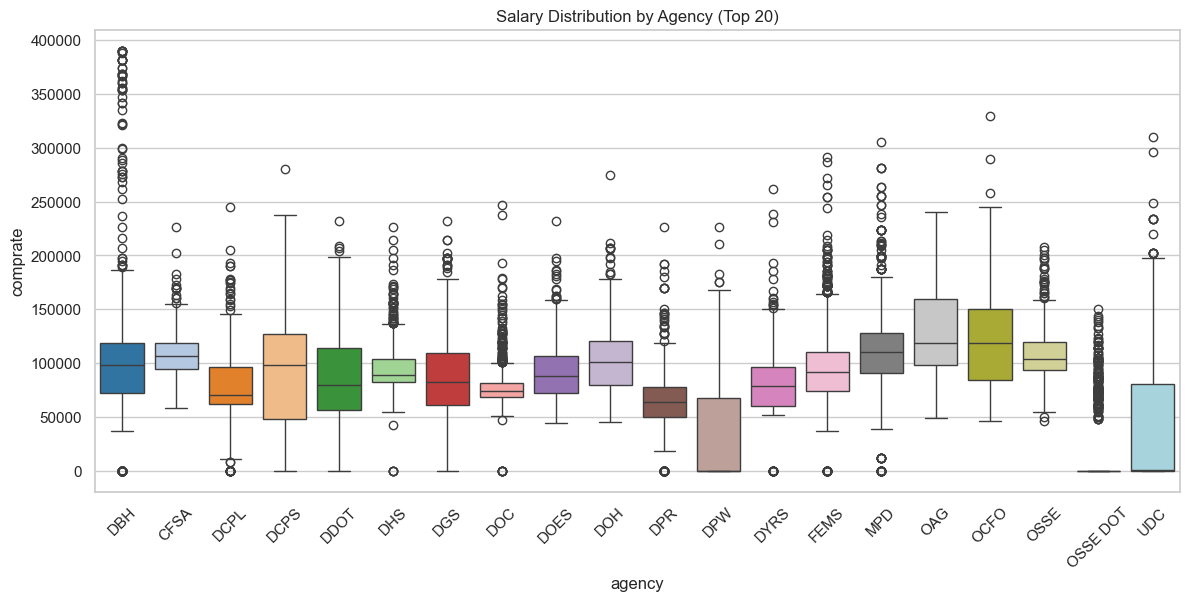

In [15]:
top_agencies = df['agency'].value_counts().head(20).index
df_top = df[df['agency'].isin(top_agencies)]

plt.figure(figsize=(14,6))
sns.boxplot(
    data=df_top,
    x='agency',
    y='comprate',
    hue='agency',        # each agency gets its own color
    palette="tab20",
    dodge=False,
    legend=False
)
plt.title("Salary Distribution by Agency (Top 20)")
plt.xticks(rotation=45)
plt.show()


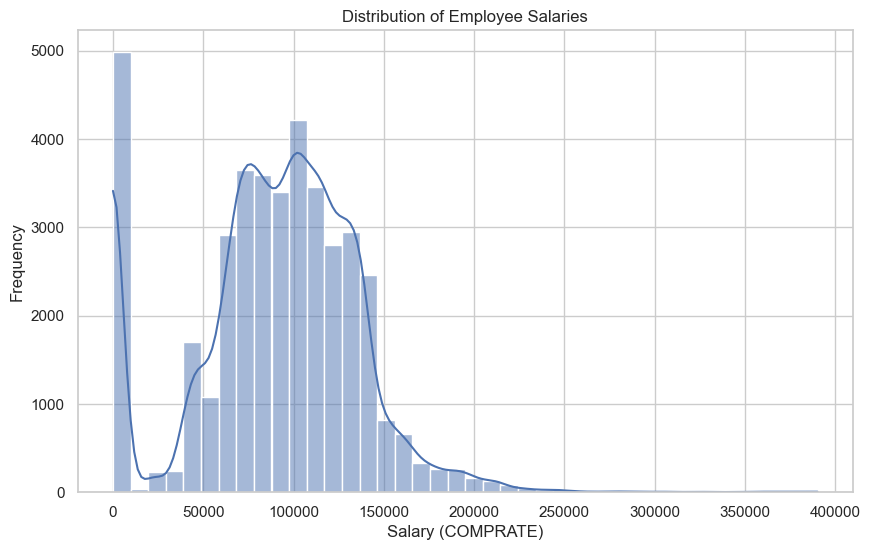

In [16]:
plt.figure(figsize=(10,6))
sns.histplot(df['comprate'], bins=40, kde=True, color="#4C72B0")
plt.title("Distribution of Employee Salaries")
plt.xlabel("Salary (COMPRATE)")
plt.ylabel("Frequency")
plt.show()


Interpretation:  
The salary distribution is right-skewed, with most employees earning between X and Y (your notebook will show exact values). A smaller number of employees earn significantly higher salaries.

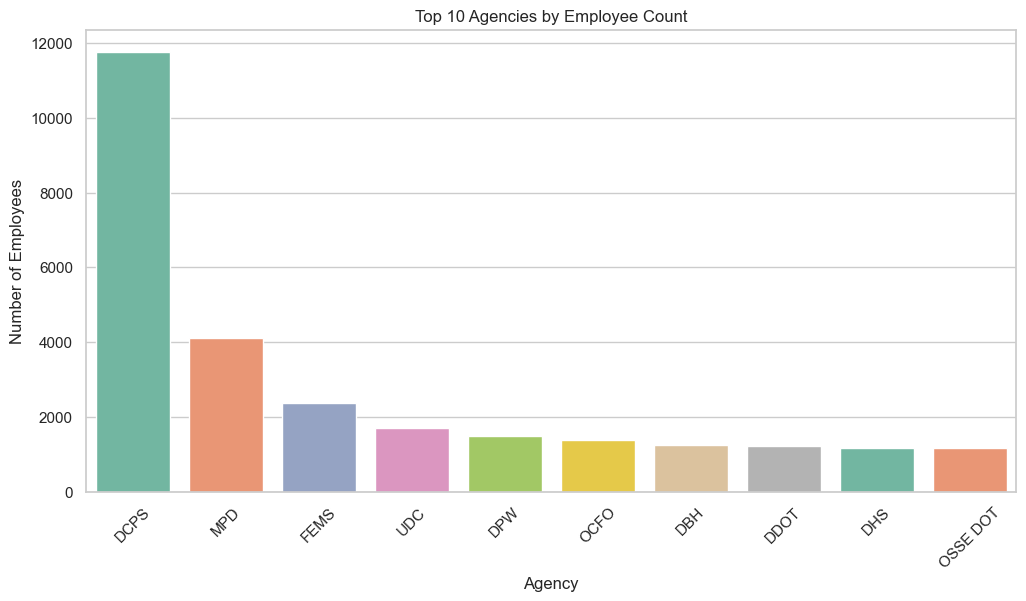

In [17]:
top_counts = df['agency'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_counts.index,
    y=top_counts.values,
    hue=top_counts.index,      # required to use palette
    palette="Set2",
    dodge=False,               # keeps bars single, not grouped
    legend=False               # hides redundant legend
)
plt.title("Top 10 Agencies by Employee Count")
plt.xlabel("Agency")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()


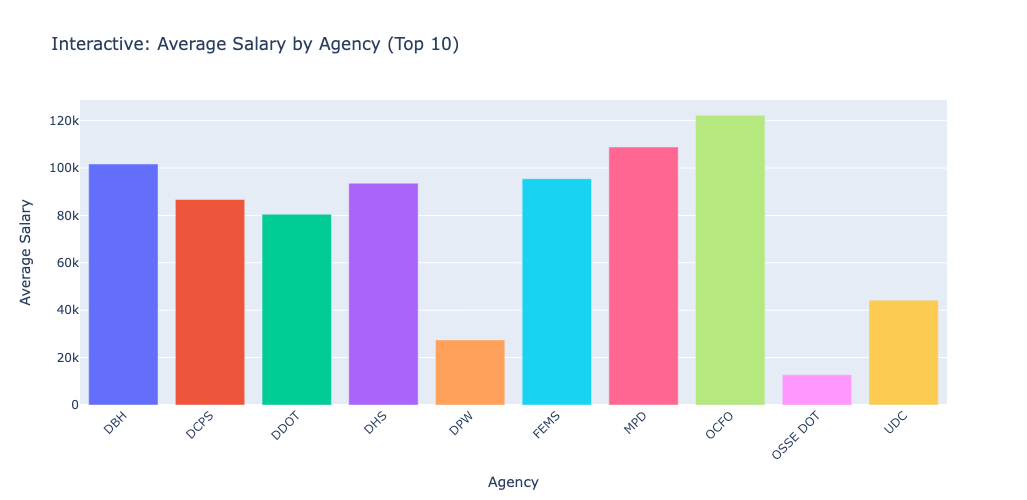

In [18]:
import plotly.express as px

# Compute top 10 agencies
top_agencies = df['agency'].value_counts().head(10).index
df_top = df[df['agency'].isin(top_agencies)]

# Compute average salary per agency
agency_avg = df_top.groupby('agency')['comprate'].mean().reset_index()

# Interactive bar chart
fig = px.bar(
    agency_avg,
    x='agency',
    y='comprate',
    color='agency',  # each bar gets a different color
    title="Interactive: Average Salary by Agency (Top 10)",
    labels={'agency': 'Agency', 'comprate': 'Average Salary'},
    hover_data={'comprate': ':.2f'}  # format hover text
)

fig.update_layout(
    xaxis_tickangle=-45,
    showlegend=False,
    height=500
)

fig.show()


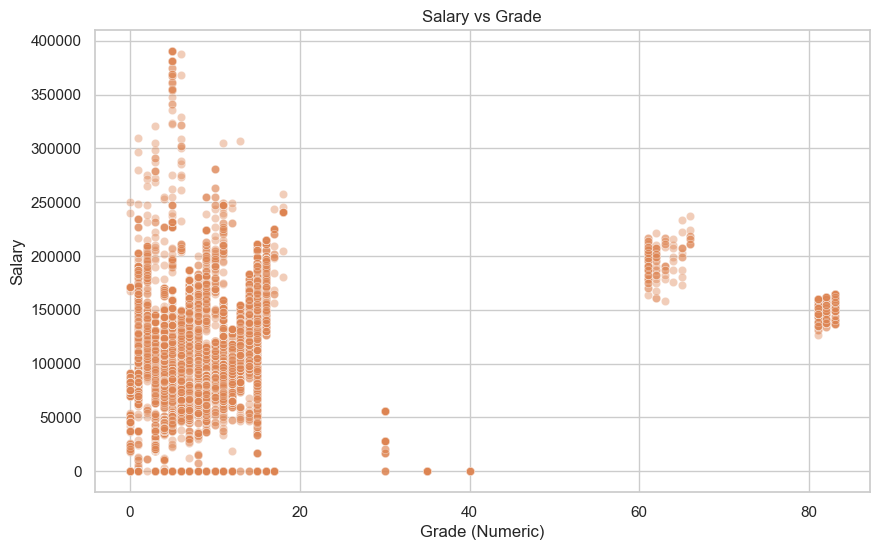

In [19]:
df['grade_numeric'] = df['grade'].astype(str).str.extract('(\d+)').astype(float)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x= 'grade_numeric',
    y='comprate',
    alpha=0.4,
    color="#DD8452"
)
plt.title("Salary vs Grade")
plt.xlabel("Grade (Numeric)")
plt.ylabel("Salary")
plt.show()




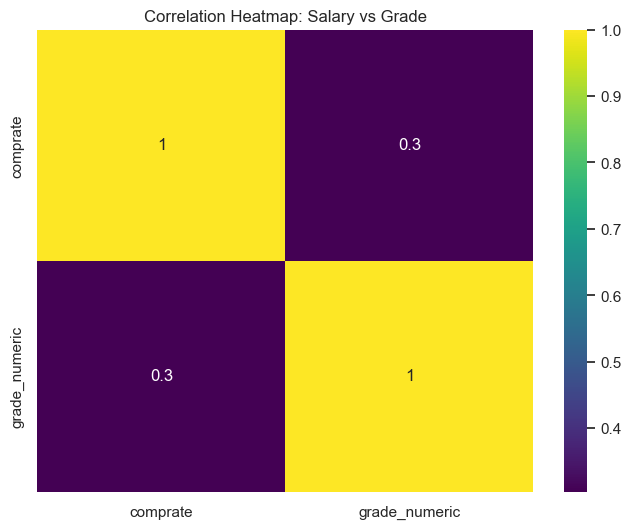

In [20]:
# Extract numeric portion of grade (e.g., "5B" → 5)
df['grade_numeric'] = df['grade'].astype(str).str.extract('(\d+)').astype(float)
plt.figure(figsize=(8,6))
sns.heatmap(df[['comprate', 'grade_numeric']].corr(), annot=True, cmap='viridis')
plt.title("Correlation Heatmap: Salary vs Grade")
plt.show()


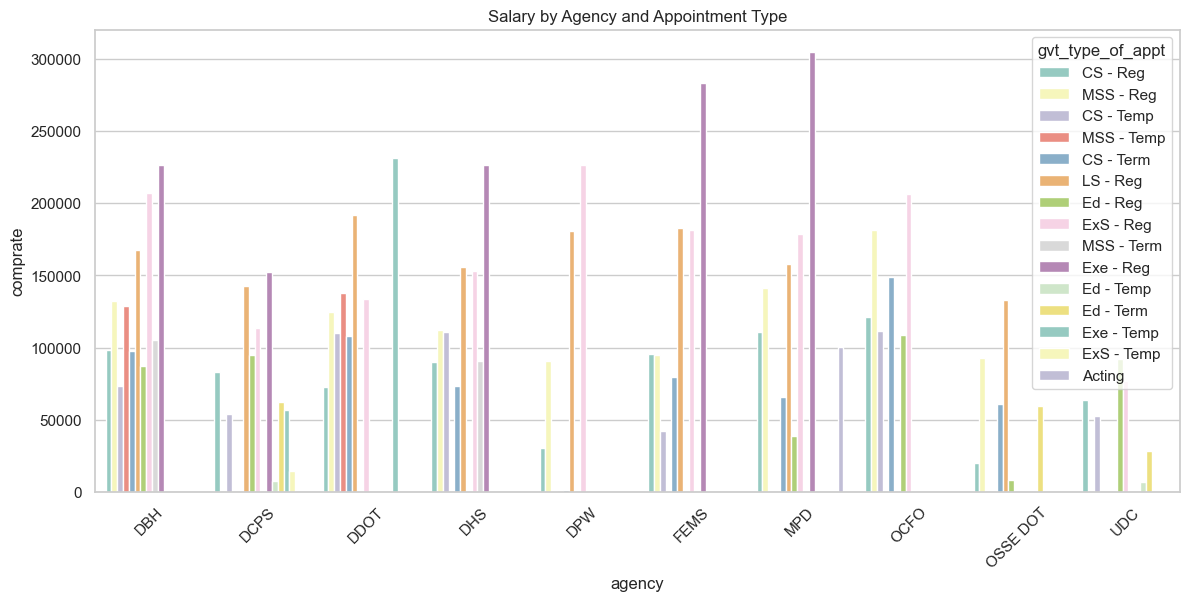

In [21]:
plt.figure(figsize=(14,6))
sns.barplot(
    data=df[df['agency'].isin(top_agencies)],
    x='agency',
    y='comprate',
    hue='gvt_type_of_appt',
    palette="Set3",
    errorbar=None
)
plt.xticks(rotation=45)
plt.title("Salary by Agency and Appointment Type")
plt.show()


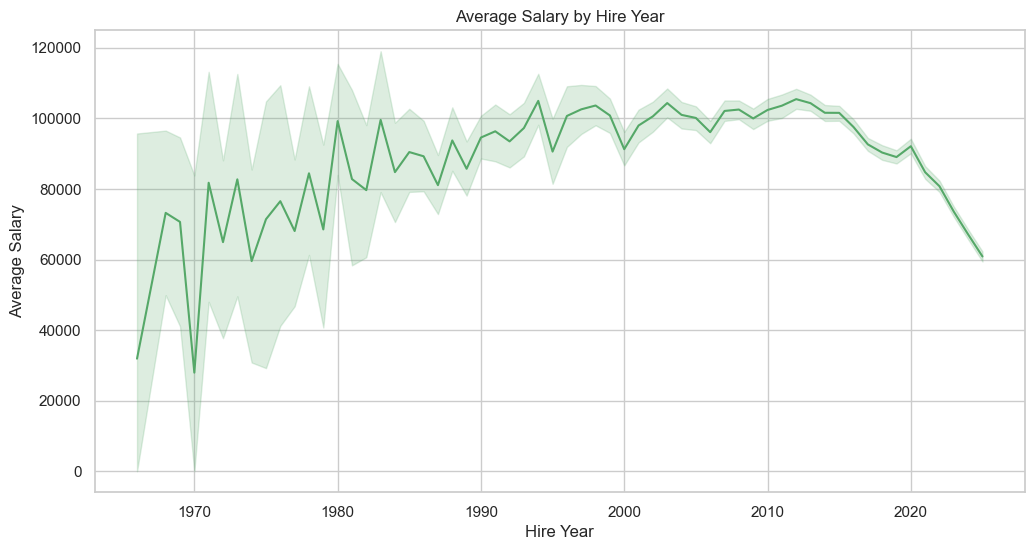

In [22]:
df['hire_year'] = df['hiredate'].dt.year

plt.figure(figsize=(12,6))
sns.lineplot(
    data=df,
    x='hire_year',
    y='comprate',
    color="#55A868"
)
plt.title("Average Salary by Hire Year")
plt.xlabel("Hire Year")
plt.ylabel("Average Salary")
plt.show()


In [23]:
top_jobs = df.groupby('jobtitle')['comprate'].mean().sort_values(ascending=False).head(20)
top_jobs


jobtitle
MEDICAL OFFICER (PSYCHIATRY)      350616.181429
MEDICAL OFFICER PSYCHIATRY        340721.737500
MEDICAL OFFICER NEUROLOGY         322505.000000
Chief Medical Examiner            320901.590000
Medical Officer (Medical Exami    312654.000000
PRESIDENT                         310000.000000
City Administrator                305100.000000
CHIEF ACADEMIC OFFICER            296506.880000
Supv Medical Officer (Psychiat    288474.770000
Executive Assistant Chief of P    281136.000000
MEDICAL OFFICER GENERAL PRACTI    280964.714286
Chancellor                        280000.000000
Chief Financial Officer           279585.716667
Medical Director                  277720.780000
MEDICAL OFFICER (MEDICAL EXAMI    275350.000000
Supv Medical Officer Psych        275203.433333
Director Department of Health     274999.990000
Fire Chief                        271623.010000
Assistant Medical Director        265295.630000
Health Services Medical Office    262000.000000
Name: comprate, dtype: float64

In [24]:
agency_salary = df.groupby('agency')['comprate'].mean().sort_values(ascending=False)
agency_salary.head(15)


agency
CJDT     187500.000000
MOLC     163643.803000
OSA      153089.606000
OEA      151215.122500
CAB      146127.447273
DCA      142048.751852
PSC      139088.642000
RHC      138841.731429
OCA      137245.592909
OLRCB    128807.598750
OP       128581.670256
DMPED    128508.198750
OAG      127638.115846
CJCC     126171.085238
HG       125681.567647
Name: comprate, dtype: float64

## Insights and Conclusion

This analysis explored salary patterns across Washington, DC public agencies. The research questions were successfully answered:

### Key Findings
- **DCPS** is the largest employer by far, with over 11,000 employees.
- **OCFO, OAG, and MPD** tend to have higher average salaries.
- Salary distributions vary widely across agencies, with some showing tight clustering and others showing large spreads.
- Higher **grade** levels are generally associated with higher salaries.
- Appointment type influences salary, with certain categories earning more on average.
- Employees hired in more recent years show different salary trends, suggesting structural changes in compensation.

### Limitations
- The dataset does not include demographic information, preventing analysis of equity or representation.
- Job titles are not standardized, which may introduce noise.
- Some agencies have small sample sizes.

### Future Directions
- Predictive modeling to estimate salary based on job features.
- Clustering analysis to group similar job roles.
- Time-series analysis of hiring trends.

Overall, this project provides a clear, data-driven view of how public salaries vary across Washington, DC agencies and job categories.
